## 0 — Imports & Setup

In [1]:
import os, sys

ROOT= os.path.expanduser('~/QIAO0042/models/ineedfood/')
os.chdir(ROOT)

print('Working dir:', os.getcwd())

Working dir: /scratch-share/QIAO0042/models/ineedfood


In [2]:
import os, zipfile, random, time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.datasets import ImageFolder

from PIL import Image
import wandb

print(f'PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# # Reproducibility
# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

PyTorch 2.10.0+cu128  |  CUDA available: True
Using device: cuda


## 2 — Data Preprocessing

In [3]:
# ── Copy pre-resized images from NFS → local /tmp (fast SSD) ─────────────────
# Images are already 100×100 in NFS_CACHE (written by preprocess.ipynb).
# This cell copies them to /tmp so dataloaders read from local disk each session.
import shutil
from pathlib import Path

NFS_CACHE   = 'dataset/food11_100x100'
LOCAL_CACHE = '/tmp/ineedfood_100x100'

def _sync_to_tmp(src_root, dst_root):
    src_root, dst_root = Path(src_root), Path(dst_root)
    for split in ('training', 'validation', 'evaluation'):
        src = src_root / split
        dst = dst_root / split
        n_src = len(list(src.rglob('*.jpg')))
        n_dst = len(list(dst.rglob('*.jpg'))) if dst.exists() else 0
        if n_dst == n_src:
            print(f'  {split:12s} — already in /tmp ({n_dst} files), skipping')
        else:
            print(f'  {split:12s} — copying {n_src} files ...')
            if dst.exists():
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            print(f'  {split:12s} — done')

print(f'Syncing {NFS_CACHE} → {LOCAL_CACHE} ...')
if not Path(LOCAL_CACHE).exists():
    _sync_to_tmp(NFS_CACHE, LOCAL_CACHE)
else:
    print(f'  Cache already exists at {LOCAL_CACHE}, skipping sync')

TRAIN_DIR = str(Path(LOCAL_CACHE) / 'training')
VAL_DIR   = str(Path(LOCAL_CACHE) / 'validation')
TEST_DIR  = str(Path(LOCAL_CACHE) / 'evaluation')
print(f'\nTRAIN_DIR → {TRAIN_DIR}')
print(f'VAL_DIR   → {VAL_DIR}')
print(f'TEST_DIR  → {TEST_DIR}')

Syncing dataset/food11_100x100 → /tmp/ineedfood_100x100 ...
  Cache already exists at /tmp/ineedfood_100x100, skipping sync

TRAIN_DIR → /tmp/ineedfood_100x100/training
VAL_DIR   → /tmp/ineedfood_100x100/validation
TEST_DIR  → /tmp/ineedfood_100x100/evaluation


In [4]:
from pathlib import Path

class Food11Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = Path(root_dir)
        self.transform = transform
        self.samples = []
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

        for p in self.root.iterdir():
            if p.is_file() and p.suffix.lower() in exts:
                stem = p.stem
                if "_" not in stem:
                    continue
                cls = int(stem.split("_")[0])   # e.g., 10_200.jpg -> 10
                self.samples.append((p, cls))

        if not self.samples:
            raise RuntimeError(f"No valid images found in {root_dir}")

        self.classes = [str(i) for i in range(11)]
        self.class_to_idx = {c: int(c) for c in self.classes}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [5]:
import json

STATS_FILE = 'dataset/stats.json'
assert os.path.exists(STATS_FILE), \
    f'{STATS_FILE} not found — run preprocess.ipynb first'

with open(STATS_FILE) as f:
    _stats = json.load(f)

MEAN        = _stats['mean']
STD         = _stats['std']
NUM_CLASSES = _stats['num_classes']
NFS_CACHE   = _stats['nfs_cache']

print(f'Loaded stats from {STATS_FILE}')
print(f'  mean        : {[f"{v:.4f}" for v in MEAN]}')
print(f'  std         : {[f"{v:.4f}" for v in STD]}')
print(f'  num_classes : {NUM_CLASSES}')
print(f'  nfs_cache   : {NFS_CACHE}')
print(f'  split sizes : {_stats["split_sizes"]}')

Loaded stats from dataset/stats.json
  mean        : ['0.5544', '0.4508', '0.3440']
  std         : ['0.2684', '0.2708', '0.2763']
  num_classes : 11
  nfs_cache   : dataset/food11_100x100
  split sizes : {'training': 9866, 'validation': 3430, 'evaluation': 3347}


In [6]:
# ── Preprocessing pipeline ────────────────────────────────────────────────────
# Images are already 100×100 on disk — no T.Resize needed.
# Training : random horizontal flip → pad 12px → random 100×100 crop → normalize
# Val/Test : normalize only (deterministic)

TRAIN_TRANSFORM = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Pad(padding=12, fill=0),
    T.RandomCrop(100),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

EVAL_TRANSFORM = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

print('Transforms defined.')

Transforms defined.


In [7]:
BATCH_SIZE = 128
NUM_WORKERS = 10

train_dataset = Food11Dataset(TRAIN_DIR, transform=TRAIN_TRANSFORM)
val_dataset   = Food11Dataset(VAL_DIR,   transform=EVAL_TRANSFORM)
test_dataset  = Food11Dataset(TEST_DIR,  transform=EVAL_TRANSFORM)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)
print(f'Classes ({NUM_CLASSES}): {train_dataset.classes}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (11): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Train: 9866 | Val: 3430 | Test: 3347


### Utility Functions (shared across all sections)

In [8]:
# ── Model factory ─────────────────────────────────────────────────────────────
def build_model(num_classes=NUM_CLASSES, pretrained=False):
    weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(DEVICE)


# BF16 autocast context
_AMP_CTX = dict(device_type=DEVICE.type, dtype=torch.bfloat16,
                enabled=False)


# ── One-epoch train / eval ────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(**_AMP_CTX):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.detach().argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.autocast(**_AMP_CTX):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


# ── Training loop ─────────────────────────────────────────────────────────────
def run_training(model, train_loader, val_loader, optimizer, criterion,
                 num_epochs, scheduler=None, tag='', wandb_run=None,
                 ckpt_path=None):
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    best_val_acc = 0.0
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            if ckpt_path is not None:
                os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
                torch.save({'epoch': epoch,
                            'model_state_dict': model.state_dict(),
                            'val_acc': vl_acc, 'val_loss': vl_loss,
                            'tag': tag}, ckpt_path)
                print(f'  [ckpt] epoch {epoch}  val_acc={vl_acc:.4f}  -> {ckpt_path}')
        if wandb_run is not None:
            wandb_run.log({
                'train_loss': tr_loss, 'val_loss': vl_loss,
                'train_acc':  tr_acc,  'val_acc':  vl_acc,
            })
        elapsed = time.time() - t0
        if epoch % 10 == 0 or epoch <= 5 or epoch == num_epochs:
            print(f'[{tag}] Epoch {epoch:3d}/{num_epochs}  '
                  f'loss {tr_loss:.4f}/{vl_loss:.4f}  '
                  f'acc {tr_acc:.3f}/{vl_acc:.3f}  '
                  f'({elapsed:.1f}s)')
    return history


# ── Plotting ──────────────────────────────────────────────────────────────────
def plot_curves(histories, labels, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors
    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], color=c, linestyle='-',  label=f'{lbl} train')
        axes[0].plot(epochs, hist['val_loss'],   color=c, linestyle='--', label=f'{lbl} val')
        axes[1].plot(epochs, hist['train_acc'],  color=c, linestyle='-',  label=f'{lbl} train')
        axes[1].plot(epochs, hist['val_acc'],    color=c, linestyle='--', label=f'{lbl} val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()


def report_final(history, tag):
    print(f'\n=== {tag} — Final Results ===')
    print(f'  Train loss : {history["train_loss"][-1]:.4f}')
    print(f'  Val   loss : {history["val_loss"][-1]:.4f}')
    print(f'  Train acc  : {history["train_acc"][-1]:.4f}')
    print(f'  Val   acc  : {history["val_acc"][-1]:.4f}')
    print(f'  Best val acc: {max(history["val_acc"]):.4f}')


print(f'Utility functions ready.  AMP enabled={_AMP_CTX["enabled"]}')


Utility functions ready.  AMP enabled=False


---
## 3 — Learning Rate
Three runs: LR ∈ {0.1, 0.025, 0.001}  |  SGD momentum=0.9  |  No weight decay  |  No schedule  |  15 epochs

In [11]:
LR_CANDIDATES = [0.1, 0.025, 0.001]
NUM_EPOCHS_LR = 15

lr_histories = {}

for lr in LR_CANDIDATES:
    print(f'\n──── LR = {lr} ────────────────────────────────────')
    run = wandb.init(
        project='ineedfood',
        name=f'sec3-lr={lr}',
        config={'section': 3, 'lr': lr, 'epochs': NUM_EPOCHS_LR,
                'optimizer': 'SGD', 'momentum': 0.9, 'weight_decay': 0.0,
                'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
    )
    model     = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                                weight_decay=0.0)
    hist = run_training(model, train_loader, val_loader,
                        optimizer, criterion,
                        num_epochs=NUM_EPOCHS_LR, tag=f'LR={lr}',
                        wandb_run=run)
    lr_histories[lr] = hist
    report_final(hist, f'LR={lr}')
    run.finish()

print('\nSection 3 done.')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/msai/qiao0042/.netrc.



──── LR = 0.1 ────────────────────────────────────


wandb: Currently logged in as: 584832452 (584832452-nanyang-technological-university-singapore) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[LR=0.1] Epoch   1/15  loss 2.5210/2.8740  acc 0.149/0.144  (3.7s)
[LR=0.1] Epoch   2/15  loss 2.2962/2.2372  acc 0.184/0.200  (3.2s)
[LR=0.1] Epoch   3/15  loss 2.2182/2.1715  acc 0.203/0.212  (3.1s)
[LR=0.1] Epoch   4/15  loss 2.1751/2.1902  acc 0.212/0.201  (3.2s)
[LR=0.1] Epoch   5/15  loss 2.1023/2.0860  acc 0.242/0.240  (3.3s)
[LR=0.1] Epoch  10/15  loss 1.8611/2.5906  acc 0.342/0.242  (3.2s)
[LR=0.1] Epoch  15/15  loss 1.6557/1.9130  acc 0.427/0.337  (3.1s)

=== LR=0.1 — Final Results ===
  Train loss : 1.6557
  Val   loss : 1.9130
  Train acc  : 0.4273
  Val   acc  : 0.3367


train_acc,▁▂▂▃▃▄▄▅▅▆▆▇▇██
train_loss,█▆▆▅▅▄▄▃▃▃▃▂▂▁▁
val_acc,▁▃▃▃▄▃▅▅▇▄▆▇██▇
val_loss,█▄▄▄▃▄▂▃▂▆▂▁▁▁▂
train_acc,0.42733
train_loss,1.65566
val_acc,0.33673
val_loss,1.91304


...

train_acc,▁▂▃▃▄▃▄▅▄▅▆▇▇██
train_loss,█▇▆▅▅▆▄▄▅▄▃▂▂▁▁
val_acc,▁▂▃▃▃▄▄▄▄▅▆▇▇██
val_loss,█▅▅▅▄▄▄▄▄▃▂▂▂▁▁
train_acc,0.54723
train_loss,1.30276
val_acc,0.5481
val_loss,1.33861



──── LR = 0.001 ────────────────────────────────────


[LR=0.001] Epoch   1/15  loss 2.3631/2.3460  acc 0.160/0.147  (3.3s)
[LR=0.001] Epoch   2/15  loss 2.2894/2.3188  acc 0.182/0.175  (3.1s)
[LR=0.001] Epoch   3/15  loss 2.2455/2.2294  acc 0.190/0.195  (3.2s)
[LR=0.001] Epoch   4/15  loss 2.1885/2.1444  acc 0.218/0.224  (3.2s)
[LR=0.001] Epoch   5/15  loss 2.1199/2.0508  acc 0.240/0.267  (3.2s)
[LR=0.001] Epoch  10/15  loss 1.8483/1.8004  acc 0.360/0.360  (3.2s)
[LR=0.001] Epoch  15/15  loss 1.6772/1.6325  acc 0.420/0.434  (3.2s)

=== LR=0.001 — Final Results ===
  Train loss : 1.6772
  Val   loss : 1.6325
  Train acc  : 0.4198
  Val   acc  : 0.4338


train_acc,▁▂▂▃▃▄▅▅▆▆▇▇▇██
train_loss,█▇▇▆▆▅▄▄▃▃▂▂▂▁▁
val_acc,▁▂▂▃▄▅▅▅▆▆▆▇▇▇█
val_loss,██▇▆▅▅▄▄▃▃▃▂▂▂▁
train_acc,0.41983
train_loss,1.67717
val_acc,0.43382
val_loss,1.63246



Section 3 done.


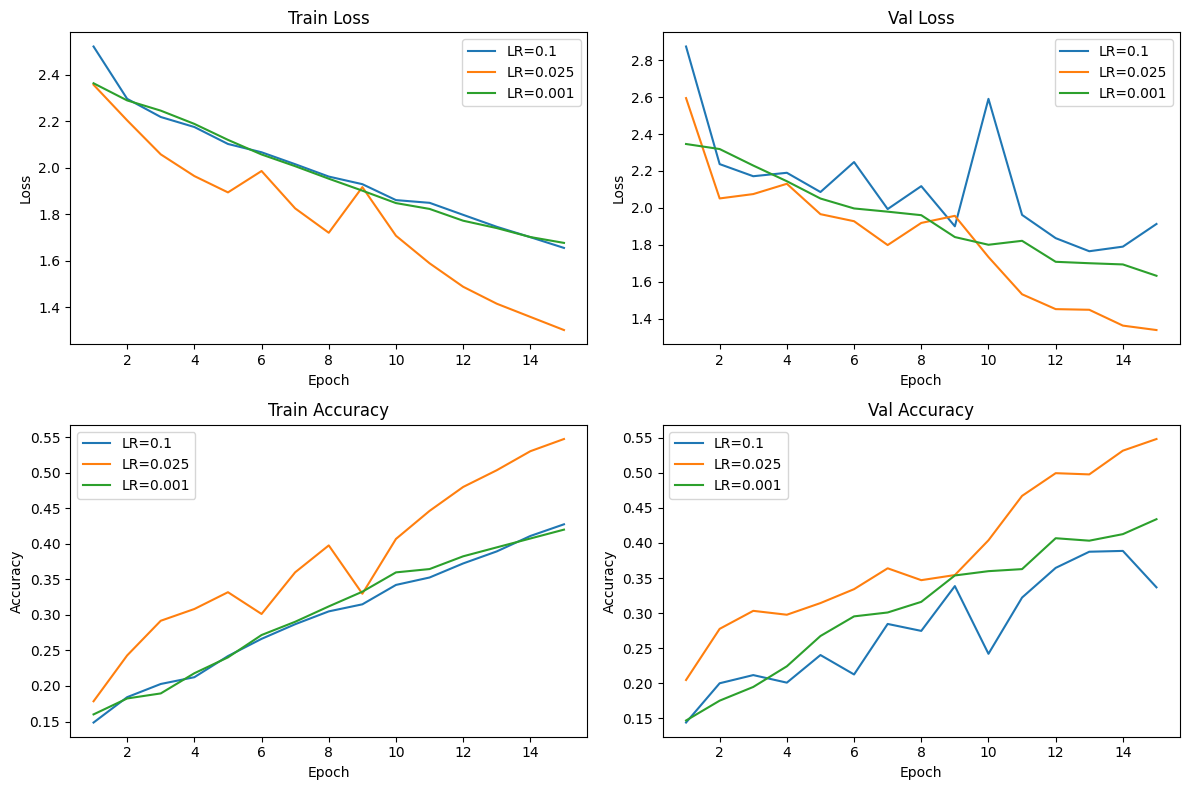

In [12]:
# plot_curves(
#     histories=[lr_histories[lr] for lr in LR_CANDIDATES],
#     labels   =[f'LR={lr}' for lr in LR_CANDIDATES],
#     title='Section 3 Learning Rate'
# )

# ── Separate train and val plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = plt.cm.tab10.colors

for i, lr in enumerate(LR_CANDIDATES):
    c = colors[i % len(colors)]
    hist = lr_histories[lr]
    epochs = range(1, len(hist['train_loss']) + 1)
    
    axes[0, 0].plot(epochs, hist['train_loss'], color=c, label=f'LR={lr}')
    axes[0, 1].plot(epochs, hist['val_loss'], color=c, label=f'LR={lr}')
    axes[1, 0].plot(epochs, hist['train_acc'], color=c, label=f'LR={lr}')
    axes[1, 1].plot(epochs, hist['val_acc'], color=c, label=f'LR={lr}')

axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss'); axes[0, 0].set_title('Train Loss'); axes[0, 0].legend()
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss'); axes[0, 1].set_title('Val Loss'); axes[0, 1].legend()
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy'); axes[1, 0].set_title('Train Accuracy'); axes[1, 0].legend()
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy'); axes[1, 1].set_title('Val Accuracy'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig('Section_3_Learning_Rate_Separated.png', dpi=150)
plt.show()

---
## 4 — Learning Rate Schedule
### 4.1 Cosine Annealing — Description
Cosine annealing smoothly reduces the learning rate following a cosine curve:

$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_0 - \eta_{\min})\left(1 + \cos\!\left(\frac{\pi\, t}{T}\right)\right)$$

where $\eta_0$ is the initial learning rate, $\eta_{\min}$ is the minimum (here 0), $t$ is the current epoch and $T$ is the total number of epochs.  
Intuitively the schedule starts fast, then decelerates gently, allowing the optimiser to refine the solution in flat basins rather than oscillating around a minimum.

### 4.2 Experiment
Two conditions, both 300 epochs with the best initial LR from Section 3:
1. **Constant LR** — no schedule
2. **Cosine annealing** — LR decays from `BEST_LR` to 0 over 300 epochs

In [13]:
BEST_LR = 0.025
criterion   = nn.CrossEntropyLoss()

In [14]:
NUM_EPOCHS_SCHED = 300

# ── Condition 1: constant LR ──────────────────────────────────────────────────
print('── Constant LR ──')
run_const   = wandb.init(
    project='ineedfood',
    name='sec4-constant-lr',
    config={'section': 4, 'lr': BEST_LR, 'epochs': NUM_EPOCHS_SCHED,
            'schedule': 'none', 'optimizer': 'SGD', 'momentum': 0.9,
            'weight_decay': 0.0, 'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
)
model_const = build_model()
opt_const   = torch.optim.SGD(model_const.parameters(), lr=BEST_LR,
                               momentum=0.9, weight_decay=0.0)
hist_const  = run_training(model_const, train_loader, val_loader,
                            opt_const, criterion,
                            num_epochs=NUM_EPOCHS_SCHED, tag='Constant',
                            wandb_run=run_const)
report_final(hist_const, 'Constant LR')
run_const.finish()

# ── Condition 2: cosine annealing ─────────────────────────────────────────────
print('\n── Cosine Annealing ──')
run_cos   = wandb.init(
    project='ineedfood',
    name='sec4-cosine-anneal',
    config={'section': 4, 'lr': BEST_LR, 'epochs': NUM_EPOCHS_SCHED,
            'schedule': 'cosine', 'optimizer': 'SGD', 'momentum': 0.9,
            'weight_decay': 0.0, 'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
)
model_cos = build_model()
opt_cos   = torch.optim.SGD(model_cos.parameters(), lr=BEST_LR,
                             momentum=0.9, weight_decay=0.0)
sched_cos = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_cos, T_max=NUM_EPOCHS_SCHED, eta_min=0.0)
hist_cos  = run_training(model_cos, train_loader, val_loader,
                          opt_cos, criterion,
                          num_epochs=NUM_EPOCHS_SCHED,
                          scheduler=sched_cos, tag='CosineAnneal',
                          wandb_run=run_cos)
report_final(hist_cos, 'Cosine Annealing')
run_cos.finish()

print('\nSection 4 done.')

── Constant LR ──


[Constant] Epoch   1/300  loss 2.3635/4.1915  acc 0.181/0.218  (3.1s)
[Constant] Epoch   2/300  loss 2.1517/2.1305  acc 0.257/0.278  (3.2s)
[Constant] Epoch   3/300  loss 2.0410/1.8858  acc 0.297/0.334  (3.3s)
[Constant] Epoch   4/300  loss 1.9224/1.9551  acc 0.333/0.338  (3.2s)
[Constant] Epoch   5/300  loss 1.8328/2.3440  acc 0.366/0.200  (3.2s)
[Constant] Epoch  10/300  loss 1.4846/1.4742  acc 0.490/0.497  (3.1s)
[Constant] Epoch  20/300  loss 1.2734/1.2607  acc 0.565/0.575  (3.0s)
[Constant] Epoch  30/300  loss 0.8414/1.1051  acc 0.709/0.644  (3.0s)
[Constant] Epoch  40/300  loss 0.5770/1.0578  acc 0.797/0.679  (3.1s)
[Constant] Epoch  50/300  loss 0.4270/1.1015  acc 0.850/0.704  (3.2s)
[Constant] Epoch  60/300  loss 0.4353/1.1288  acc 0.846/0.682  (3.1s)
[Constant] Epoch  70/300  loss 0.2988/1.1685  acc 0.897/0.708  (3.2s)
[Constant] Epoch  80/300  loss 0.2885/1.2079  acc 0.902/0.710  (3.2s)
[Constant] Epoch  90/300  loss 0.2156/1.2354  acc 0.923/0.722  (3.2s)
[Constant] Epoch 100

train_acc,▁▃▄▄▆▆▆▆▇▇▇█▆▇▇▇▇████▇██████████████████
train_loss,█▇▅▄▄▃▂▂▂▂▂▂▂▂▂▂▁▃▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▅▆▆▇▇▇▇▇██▇▇█▇████████████████████████
val_loss,█▃▃▂▂▁▁▁▁▁▁▁▁▁▂▂▁▂▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
train_acc,0.98084
train_loss,0.05587
val_acc,0.74169
val_loss,1.50585



── Cosine Annealing ──


[CosineAnneal] Epoch   1/300  loss 2.3914/7.4217  acc 0.177/0.169  (3.2s)
[CosineAnneal] Epoch   2/300  loss 2.2070/2.4056  acc 0.244/0.285  (3.2s)
[CosineAnneal] Epoch   3/300  loss 2.0288/2.2390  acc 0.298/0.301  (3.1s)
[CosineAnneal] Epoch   4/300  loss 1.9087/1.8580  acc 0.333/0.352  (3.2s)
[CosineAnneal] Epoch   5/300  loss 1.8554/1.8399  acc 0.354/0.379  (3.2s)
[CosineAnneal] Epoch  10/300  loss 1.5025/1.6253  acc 0.485/0.447  (3.2s)
[CosineAnneal] Epoch  20/300  loss 1.0169/1.1771  acc 0.649/0.609  (3.2s)
[CosineAnneal] Epoch  30/300  loss 0.7993/1.1351  acc 0.729/0.636  (3.3s)
[CosineAnneal] Epoch  40/300  loss 1.1725/1.1241  acc 0.601/0.628  (3.2s)
[CosineAnneal] Epoch  50/300  loss 0.5380/1.0173  acc 0.815/0.695  (3.1s)
[CosineAnneal] Epoch  60/300  loss 0.6574/1.0083  acc 0.773/0.687  (3.2s)
[CosineAnneal] Epoch  70/300  loss 0.3132/1.2038  acc 0.888/0.696  (3.1s)
[CosineAnneal] Epoch  80/300  loss 0.3178/1.1863  acc 0.893/0.705  (3.2s)
[CosineAnneal] Epoch  90/300  loss 0.2

train_acc,▁▃▄▅▅▅▆▆▆▆▇▇▇▇▇█▇▇██████████████████████
train_loss,█▇▄▆▄▃▄▂▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▄▄▄▇▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇█████████████▇██
val_loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
train_acc,0.99747
train_loss,0.00839
val_acc,0.73324
val_loss,1.63474



Section 4 done.


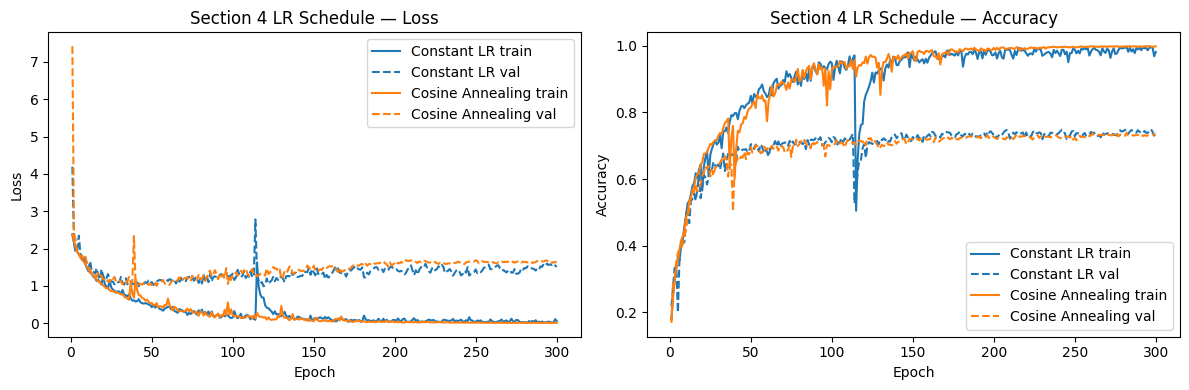

In [15]:
plot_curves(
    histories=[hist_const, hist_cos],
    labels   =['Constant LR', 'Cosine Annealing'],
    title='Section 4 LR Schedule'
)

---
## 5 — Weight Decay
Best LR + cosine annealing + weight decay λ ∈ {5×10⁻⁴, 1×10⁻⁴} | 300 epochs

In [16]:
WD_VALUES = [5e-4, 1e-4]
NUM_EPOCHS_WD = 300

wd_histories = {}

In [17]:

for wd in WD_VALUES:
    print(f'\n──── Weight Decay λ = {wd} ────────────────────────')
    run = wandb.init(
        project='ineedfood',
        name=f'sec5-wd={wd}',
        config={'section': 5, 'lr': BEST_LR, 'weight_decay': wd,
                'epochs': NUM_EPOCHS_WD, 'schedule': 'cosine',
                'optimizer': 'SGD', 'momentum': 0.9,
                'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
    )
    model_wd = build_model()
    opt_wd   = torch.optim.SGD(model_wd.parameters(), lr=BEST_LR,
                                momentum=0.9, weight_decay=wd)
    sched_wd = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt_wd, T_max=NUM_EPOCHS_WD, eta_min=0.0)
    hist_wd  = run_training(model_wd, train_loader, val_loader,
                             opt_wd, criterion,
                             num_epochs=NUM_EPOCHS_WD,
                             scheduler=sched_wd, tag=f'WD={wd}',
                             wandb_run=run)
    wd_histories[wd] = hist_wd
    report_final(hist_wd, f'Weight Decay λ={wd}')
    run.finish()

print('\nSection 5 done.')


──── Weight Decay λ = 0.0005 ────────────────────────


[WD=0.0005] Epoch   1/300  loss 2.3278/5.0269  acc 0.185/0.148  (3.2s)
[WD=0.0005] Epoch   2/300  loss 2.1473/2.5362  acc 0.268/0.292  (3.2s)
[WD=0.0005] Epoch   3/300  loss 2.0158/2.4486  acc 0.291/0.322  (3.3s)
[WD=0.0005] Epoch   4/300  loss 1.8917/2.1206  acc 0.340/0.322  (3.2s)
[WD=0.0005] Epoch   5/300  loss 1.7915/1.7670  acc 0.380/0.401  (3.1s)
[WD=0.0005] Epoch  10/300  loss 1.4240/1.5784  acc 0.506/0.464  (3.3s)
[WD=0.0005] Epoch  20/300  loss 1.0484/1.2284  acc 0.642/0.587  (3.1s)
[WD=0.0005] Epoch  30/300  loss 0.8457/1.1436  acc 0.710/0.624  (3.2s)
[WD=0.0005] Epoch  40/300  loss 0.7098/1.1641  acc 0.756/0.651  (3.3s)
[WD=0.0005] Epoch  50/300  loss 0.6082/1.0504  acc 0.790/0.670  (3.2s)
[WD=0.0005] Epoch  60/300  loss 0.5302/0.9621  acc 0.820/0.697  (3.2s)
[WD=0.0005] Epoch  70/300  loss 0.4849/1.0009  acc 0.832/0.690  (3.2s)
[WD=0.0005] Epoch  80/300  loss 0.3915/0.9632  acc 0.866/0.710  (3.2s)
[WD=0.0005] Epoch  90/300  loss 0.4814/0.9734  acc 0.834/0.716  (3.2s)
[WD=0.

train_acc,▁▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████
train_loss,█▇▆▆▆▄▅▄▄▄▅▃▂▃▂▂▂▂▂▂▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▅▅▅▄▅▆▅▆▅▆▁▅▇▅▇▆▇▆▆▆▇███████████████████
val_loss,█▆▄▂▂█▂▂▁▂▂▁▃▁▁▂▃▂▄▁▁▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
train_acc,0.99736
train_loss,0.01426
val_acc,0.76472
val_loss,1.03594



──── Weight Decay λ = 0.0001 ────────────────────────


[WD=0.0001] Epoch   1/300  loss 2.3825/3.3535  acc 0.184/0.175  (3.2s)
[WD=0.0001] Epoch   2/300  loss 2.1768/2.0833  acc 0.246/0.252  (3.2s)
[WD=0.0001] Epoch   3/300  loss 2.0118/2.1474  acc 0.289/0.306  (3.3s)
[WD=0.0001] Epoch   4/300  loss 1.9298/1.9685  acc 0.328/0.329  (3.2s)
[WD=0.0001] Epoch   5/300  loss 1.8927/1.8498  acc 0.332/0.352  (3.2s)
[WD=0.0001] Epoch  10/300  loss 1.4721/1.5534  acc 0.492/0.468  (3.2s)
[WD=0.0001] Epoch  20/300  loss 0.9823/1.1908  acc 0.669/0.618  (3.3s)
[WD=0.0001] Epoch  30/300  loss 0.7718/1.0649  acc 0.738/0.650  (3.2s)
[WD=0.0001] Epoch  40/300  loss 0.6161/1.3082  acc 0.783/0.621  (3.2s)
[WD=0.0001] Epoch  50/300  loss 0.9083/1.1324  acc 0.683/0.627  (3.3s)
[WD=0.0001] Epoch  60/300  loss 0.5071/1.1323  acc 0.823/0.667  (3.3s)
[WD=0.0001] Epoch  70/300  loss 0.4577/1.2245  acc 0.839/0.652  (3.1s)
[WD=0.0001] Epoch  80/300  loss 0.4411/1.1415  acc 0.844/0.686  (3.3s)
[WD=0.0001] Epoch  90/300  loss 0.4222/1.1962  acc 0.853/0.672  (3.1s)
[WD=0.

train_acc,▁▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███████████████████████
train_loss,█▅▄▄▃▃▃▅▃▂▂▂▂▂▂▂▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▅▇▇▇▇▇▇▇▇█▇██████████████████████████
val_loss,▂▄▂▁▁▁▁█▁▁▁▁▂▁▁▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
train_acc,0.99797
train_loss,0.00931
val_acc,0.71749
val_loss,1.66723



Section 5 done.


In [10]:
# Compare: no weight decay (cosine, Section 4) vs two WD values
plot_curves(
    histories=[hist_cos] + [wd_histories[wd] for wd in WD_VALUES],
    labels   =['No WD (cosine)'] + [f'WD λ={wd}' for wd in WD_VALUES],
    title='Section 5 Weight Decay'
)

NameError: name 'hist_cos' is not defined

---
## 6 — Data Augmentation: Mixup (α = 0.2)

### Beta Distribution PDF (α = β = 0.2)

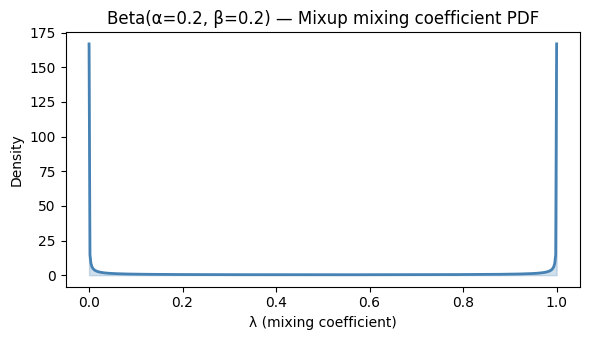

The U-shaped PDF concentrates mass near 0 and 1, so most mixed samples are close to one of the two originals.


In [9]:
from scipy.stats import beta as beta_dist

alpha_mixup = 0.2
x = np.linspace(1e-4, 1 - 1e-4, 500)
pdf = beta_dist.pdf(x, a=alpha_mixup, b=alpha_mixup)

plt.figure(figsize=(6, 3.5))
plt.plot(x, pdf, color='steelblue', linewidth=2)
plt.fill_between(x, pdf, alpha=0.25, color='steelblue')
plt.xlabel('λ (mixing coefficient)')
plt.ylabel('Density')
plt.title(f'Beta(α={alpha_mixup}, β={alpha_mixup}) — Mixup mixing coefficient PDF')
plt.tight_layout()
plt.savefig('beta_pdf.png', dpi=150)
plt.show()
print('The U-shaped PDF concentrates mass near 0 and 1, '
      'so most mixed samples are close to one of the two originals.')

In [10]:
# ── Mixup helpers ─────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x  = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_one_epoch_mixup(model, loader, optimizer, criterion, alpha=0.2):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        mixed, y_a, y_b, lam = mixup_data(imgs, labels, alpha=alpha)
        optimizer.zero_grad()
        with torch.autocast(**_AMP_CTX):
            logits = model(mixed)
            loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        pred = logits.detach().argmax(1)
        correct += (lam * (pred == y_a).float() +
                    (1 - lam) * (pred == y_b).float()).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


def run_training_mixup(model, train_loader, val_loader, optimizer, criterion,
                       num_epochs, scheduler=None, alpha=0.2, tag='',
                       wandb_run=None, ckpt_path=None):
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    best_val_acc = 0.0
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch_mixup(model, train_loader,
                                                 optimizer, criterion, alpha)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            if ckpt_path is not None:
                os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
                torch.save({'epoch': epoch,
                            'model_state_dict': model.state_dict(),
                            'val_acc': vl_acc, 'val_loss': vl_loss,
                            'tag': tag}, ckpt_path)
                print(f'  [ckpt] epoch {epoch}  val_acc={vl_acc:.4f}  -> {ckpt_path}')
        if wandb_run is not None:
            wandb_run.log({
                f'{tag}/train_loss': tr_loss, f'{tag}/val_loss': vl_loss,
                f'{tag}/train_acc':  tr_acc,  f'{tag}/val_acc':  vl_acc,
                f'{tag}/epoch':      epoch,
            })
        elapsed = time.time() - t0
        if epoch % 10 == 0 or epoch <= 5 or epoch == num_epochs:
            print(f'[{tag}] Epoch {epoch:3d}/{num_epochs}  '
                  f'loss {tr_loss:.4f}/{vl_loss:.4f}  '
                  f'acc {tr_acc:.3f}/{vl_acc:.3f}  '
                  f'({elapsed:.1f}s)')
    return history


print('Mixup helpers ready.')


Mixup helpers ready.


In [11]:
# Best setup so far: BEST_LR + cosine annealing + best weight decay
BEST_WD = 5e-4
print(f'Best weight decay from Section 5: {BEST_WD}')

Best weight decay from Section 5: 0.0005


In [20]:
NUM_EPOCHS_MIX = 300
ALPHA_MIXUP    = 0.2
CKPT_SEC6      = 'checkpoints/sec6_mixup_best.pth'

print('\n── Mixup (α=0.2) ──')
run_mix = wandb.init(
    project='ineedfood',
    name='sec6-mixup-a0.2',
    config={'section': 6, 'lr': BEST_LR, 'weight_decay': BEST_WD,
            'epochs': NUM_EPOCHS_MIX, 'schedule': 'cosine',
            'mixup': True, 'mixup_alpha': ALPHA_MIXUP,
            'optimizer': 'SGD', 'momentum': 0.9,
            'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
)
model_mix = build_model()
opt_mix   = torch.optim.SGD(model_mix.parameters(), lr=BEST_LR,
                             momentum=0.9, weight_decay=BEST_WD)
sched_mix = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_mix, T_max=NUM_EPOCHS_MIX, eta_min=0.0)
criterion = nn.CrossEntropyLoss()
hist_mix  = run_training_mixup(model_mix, train_loader, val_loader,
                                opt_mix, criterion,
                                num_epochs=NUM_EPOCHS_MIX,
                                scheduler=sched_mix,
                                alpha=ALPHA_MIXUP, tag='Mixup',
                                wandb_run=run_mix,
                                ckpt_path=CKPT_SEC6)
report_final(hist_mix, 'Mixup α=0.2')
print(f'Best checkpoint saved to: {CKPT_SEC6}')
print('\nSection 6 done.')



── Mixup (α=0.2) ──


Mixup/epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
Mixup/train_acc,▁▂▃▃▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇█▇▇▇▇▇██
Mixup/train_loss,█▇▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▁▂▂▂▂▂▁▁
Mixup/val_acc,▁▂▁▃▃▄▄▅▅▆▆▇▆▆▇▇▇▇█▇▇▇██▇██
Mixup/val_loss,█▃▃▂▃▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
Mixup/epoch,27
Mixup/train_acc,0.61478
Mixup/train_loss,1.21636
Mixup/val_acc,0.63848
Mixup/val_loss,1.06111


  [ckpt] epoch 1  val_acc=0.2335  -> checkpoints/sec6_mixup_best.pth
[Mixup] Epoch   1/300  loss 2.3708/2.4976  acc 0.183/0.234  (3.3s)
  [ckpt] epoch 2  val_acc=0.2691  -> checkpoints/sec6_mixup_best.pth
[Mixup] Epoch   2/300  loss 2.1686/2.0942  acc 0.237/0.269  (3.3s)
  [ckpt] epoch 3  val_acc=0.3108  -> checkpoints/sec6_mixup_best.pth
[Mixup] Epoch   3/300  loss 2.0479/1.9301  acc 0.273/0.311  (3.3s)
  [ckpt] epoch 4  val_acc=0.3440  -> checkpoints/sec6_mixup_best.pth
[Mixup] Epoch   4/300  loss 1.9927/1.8395  acc 0.297/0.344  (3.4s)
[Mixup] Epoch   5/300  loss 1.9697/1.9454  acc 0.312/0.321  (3.3s)
  [ckpt] epoch 6  val_acc=0.3700  -> checkpoints/sec6_mixup_best.pth
  [ckpt] epoch 7  val_acc=0.3936  -> checkpoints/sec6_mixup_best.pth
  [ckpt] epoch 8  val_acc=0.4312  -> checkpoints/sec6_mixup_best.pth
  [ckpt] epoch 10  val_acc=0.4627  -> checkpoints/sec6_mixup_best.pth
[Mixup] Epoch  10/300  loss 1.7234/1.5811  acc 0.413/0.463  (3.1s)
  [ckpt] epoch 11  val_acc=0.4711  -> checkpo

In [21]:
import wandb
import matplotlib.pyplot as plt

WANDB_ENTITY  = '584832452-nanyang-technological-university-singapore'
WANDB_PROJECT = 'ineedfood'

def fetch_history(run_id, tag=None):
    """
    Retrieve training history from a wandb run, matching the dict format
    returned by run_training:
        {'train_loss': [...], 'val_loss': [...],
         'train_acc':  [...], 'val_acc':  [...]}

    Parameters
    ----------
    run_id : str
        Short run ID (e.g. 'tin2g81l') or full 'entity/project/run_id'.
    tag : str, optional
        Metric prefix logged as '{tag}/train_loss' etc.
        If None, auto-detected. Pass tag='' for bare keys.

    Returns
    -------
    history : dict  – same structure as run_training output
    config  : dict  – hyperparameters stored in the run config
    """
    api  = wandb.Api()
    path = run_id if '/' in run_id else f'{WANDB_ENTITY}/{WANDB_PROJECT}/{run_id}'
    run  = api.run(path)

    df = run.history(samples=10_000, pandas=True)

    # ── Auto-detect tag prefix ────────────────────────────────────────────────
    if tag is None:
        prefixed = [c for c in df.columns if c.endswith('/train_loss')]
        tag = prefixed[0].replace('/train_loss', '') if prefixed else ''

    prefix = f'{tag}/' if tag else ''
    keys = {
        'train_loss': f'{prefix}train_loss',
        'val_loss':   f'{prefix}val_loss',
        'train_acc':  f'{prefix}train_acc',
        'val_acc':    f'{prefix}val_acc',
    }

    missing = [v for v in keys.values() if v not in df.columns]
    if missing:
        available_tags = list({c.rsplit('/', 1)[0] for c in df.columns if '/' in c})
        raise KeyError(
            f"Keys {missing} not found in run '{run.name}'.\n"
            f"  Available tags : {available_tags}\n"
            f"  All keys       : {sorted(df.columns.tolist())}\n"
            f"  Hint: pass tag= explicitly, e.g. fetch_history('{run_id}', tag='{available_tags[0] if available_tags else ''}')"
        )

    sub = df[list(keys.values())].dropna()
    history = {k: sub[v].tolist() for k, v in keys.items()}

    # run.config values are plain Python objects via the API
    config = {k: v for k, v in run.config.items() if not k.startswith('_')}

    print(f"Run  : {run.name}  ({run.id})")
    print(f"Tag  : '{tag}'  |  Steps recovered: {len(sub)}")
    print(f"Config: {config}")
    return history, config


def list_runs(name_filter=None):
    """Print a table of all runs in the project."""
    api  = wandb.Api()
    runs = api.runs(f'{WANDB_ENTITY}/{WANDB_PROJECT}')
    print(f'{"ID":>10}  {"Name":<30}  {"State":>8}  {"Steps":>6}')
    print('-' * 62)
    for r in runs:
        if name_filter and name_filter not in r.name:
            continue
        steps = r.summary.get('_step', '?')
        print(f'{r.id:>10}  {r.name:<30}  {r.state:>8}  {steps!s:>6}')

def plot_curves(histories, labels, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors
    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], color=c, linestyle='-',  label=f'{lbl} train')
        axes[0].plot(epochs, hist['val_loss'],   color=c, linestyle='--', label=f'{lbl} val')
        axes[1].plot(epochs, hist['train_acc'],  color=c, linestyle='-',  label=f'{lbl} train')
        axes[1].plot(epochs, hist['val_acc'],    color=c, linestyle='--', label=f'{lbl} val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

print('wandb history utilities ready.')

wandb history utilities ready.


In [22]:
list_runs()

        ID  Name                               State   Steps
--------------------------------------------------------------
  uozjz9kt  sec3-lr-search                  finished      44
  utghr67i  sec3-lr=0.1                     finished      14
  24p8jikf  sec3-lr=0.025                   finished      14
  ffpy4gb8  sec3-lr=0.001                   finished      14
  ebbk4dtx  sec3-lr=0.1                     finished      14
  bbph2f3s  sec3-lr=0.025                   finished      14
  0ki1ri4a  sec3-lr=0.001                   finished      14
  32e80fkr  sec4-constant-lr                finished     299
  dbwxp3o2  sec4-cosine-anneal              finished     299
  1e9bux0p  sec5-wd=0.0005                  finished     299
  83fad58g  sec5-wd=0.0001                   crashed       9
  mafb82ab  sec5-wd=0.0001                  finished       ?
  tin2g81l  sec5-wd=0.0001                  finished     299
  jw6dlh6h  sec6-no-mixup                   finished       4
  zcdbwlvk  sec6-mixup

In [23]:
hist_base, _ = fetch_history('dfch7clz')

Run  : sec5-wd=0.0005  (dfch7clz)
Tag  : ''  |  Steps recovered: 300
Config: {'lr': 0.025, 'model': 'EfficientNet-B0', 'epochs': 300, 'section': 5, 'momentum': 0.9, 'schedule': 'cosine', 'optimizer': 'SGD', 'batch_size': 128, 'weight_decay': 0.0005}


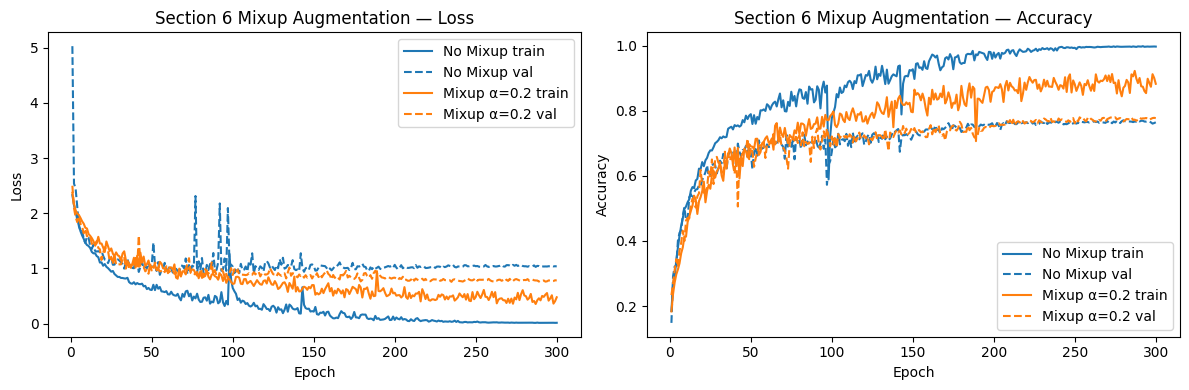

In [24]:
plot_curves(
    histories=[hist_base, hist_mix],
    labels   =['No Mixup', 'Mixup α=0.2'],
    title='Section 6 Mixup Augmentation'
)

In [25]:
# ── Final test-set accuracy ───────────────────────────────────────────────────
criterion_eval = nn.CrossEntropyLoss()

# Mixup model — evaluated fresh on test set
test_loss_mix, test_acc_mix = evaluate(model_mix, test_loader, criterion_eval)

print('=== Hold-out Test Set Results ===')
print(f'  No Mixup (sec5 baseline) — val acc : {hist_base["val_acc"][-1]:.4f}  (test eval skipped, model not retained)')
print(f'  Mixup 0.2               — test acc : {test_acc_mix:.4f} ({test_acc_mix*100:.2f}%)')

run_mix.summary['test_loss'] = test_loss_mix
run_mix.summary['test_acc']  = test_acc_mix
run_mix.finish()

=== Hold-out Test Set Results ===
  No Mixup (sec5 baseline) — val acc : 0.7647  (test eval skipped, model not retained)
  Mixup 0.2               — test acc : 0.7935 (79.35%)


Mixup/epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
Mixup/train_acc,▁▃▄▅▅▅▆▆▆▇▇▇▇▇▆▇▇▆▇▇▇▇▇▇▇▇████████▇████▇
Mixup/train_loss,██▇▆▆▆▅▅▅▅▄▄▃▄▃▃▂▄▂▃▃▂▂▂▂▁▂▁▂▁▂▂▂▂▂▁▂▂▂▂
Mixup/val_acc,▁▂▅▅▆▆▆▆▇▇▇▇▇▇▇▇█▇▇▇▇██▇▇███████████████
Mixup/val_loss,█▆▆▄▄▃▄▄▂▃▂▂▃▂▂▂▂▂▁▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Mixup/epoch,300
Mixup/train_acc,0.88304
Mixup/train_loss,0.47642
Mixup/val_acc,0.77755
Mixup/val_loss,0.78032
test_acc,0.79355


In [49]:
# Compact summary for the trained Mixup model
def summarize_model(model, optimizer=None, model_name='model_mix'):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f'=== {model_name} summary ===')
    print(f'Type               : {model.__class__.__name__}')
    print(f'Device             : {next(model.parameters()).device}')
    print(f'Total parameters   : {total_params:,}')
    print(f'Trainable params   : {trainable_params:,}')
    print(f'Frozen params      : {total_params - trainable_params:,}')

    if hasattr(model, "classifier"):
        print(f'Classifier head    : {model.classifier}')
        if isinstance(model.classifier, nn.Sequential) and len(model.classifier) > 1:
            last = model.classifier[-1]
            if isinstance(last, nn.Linear):
                print(f'Output classes     : {last.out_features}')

    if optimizer is not None:
        pg = optimizer.param_groups[0]
        print('Optimizer          :', optimizer.__class__.__name__)
        print(f'  lr={pg.get("lr")}  momentum={pg.get("momentum")}  weight_decay={pg.get("weight_decay")}')

summarize_model(model_mix, optimizer=opt_mix)
print(f'Latest test acc    : {test_acc_mix:.4f}')
print(f'Latest test loss   : {test_loss_mix:.4f}')

=== model_mix summary ===
Type               : EfficientNet
Device             : cuda:0
Total parameters   : 4,021,639
Trainable params   : 4,021,639
Frozen params      : 0
Classifier head    : Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=11, bias=True)
)
Output classes     : 11
Optimizer          : SGD
  lr=0.0  momentum=0.9  weight_decay=0.0005
Latest test acc    : 0.7935
Latest test loss   : 0.6985


In [50]:
# ── Model Summary ─────────────────────────────────────────────────────────────
summary_model = build_model()

total_params    = sum(p.numel() for p in summary_model.parameters())
trainable_params = sum(p.numel() for p in summary_model.parameters() if p.requires_grad)

print('=' * 52)
print('  EfficientNet-B0  —  Food-11 (11 classes)')
print('=' * 52)
print(f'  {"Layer group":<20} {"Params":>12}')
print('-' * 52)
block_names = [
    'Stem (Conv+BN)',
    'MBConv1  1×  (stage 1)',
    'MBConv6  2×  (stage 2)',
    'MBConv6  2×  (stage 3)',
    'MBConv6  3×  (stage 4)',
    'MBConv6  3×  (stage 5)',
    'MBConv6  4×  (stage 6)',
    'MBConv6  1×  (stage 7)',
    'Head Conv+BN',
]
for name, module in summary_model.features.named_children():
    p = sum(x.numel() for x in module.parameters())
    label = block_names[int(name)]
    print(f'  {label:<32} {p:>10,}')
print('-' * 52)
print(f'  {"Classifier (Linear 1280→11)":<32} {14_091:>10,}')
print('=' * 52)
print(f'  {"Total parameters":<32} {total_params:>10,}')
print(f'  {"Trainable parameters":<32} {trainable_params:>10,}')
print(f'  {"Non-trainable parameters":<32} {total_params - trainable_params:>10,}')
print(f'  {"Model size (FP32)":<32} {total_params*4/1e6:>9.2f} MB')
print('=' * 52)
del summary_model

  EfficientNet-B0  —  Food-11 (11 classes)
  Layer group                Params
----------------------------------------------------
  Stem (Conv+BN)                          928
  MBConv1  1×  (stage 1)                1,448
  MBConv6  2×  (stage 2)               16,714
  MBConv6  2×  (stage 3)               46,640
  MBConv6  3×  (stage 4)              242,930
  MBConv6  3×  (stage 5)              543,148
  MBConv6  4×  (stage 6)            2,026,348
  MBConv6  1×  (stage 7)              717,232
  Head Conv+BN                        412,160
----------------------------------------------------
  Classifier (Linear 1280→11)          14,091
  Total parameters                  4,021,639
  Trainable parameters              4,021,639
  Non-trainable parameters                  0
  Model size (FP32)                    16.09 MB
